# Female Powerlifting Time Series EDA
**Alex Bevan**

<span id="the-dataset"></span>
## The Dataset
1. **Dataset description and background:** Affiliated with the OpenPowerlifting website and database which curates data from **1975 to 2019 and offers some 800K observations.** It is currently overseen by eight professional powerlifters. 
2. **How it qualifies as a time series:** Competitions (known as "Meets" in powerlifting) meet annually, but I have aggregated the data to be monthly, **taking the best overall total "TotalKg" per month.** Powerlifting totals combine the weights lifted across the benchpress, squat and deadlift. 
3. **What am I trying to forecast? The target variable is TotalKg,** the best overall Total lifted by a competitior across Meets in that month. I want to forecast the total weight for women into the future which would **provdie a good guage for competitors in terms of where their lifts need to be** in order to be competitive. 
4. **Which metrics will be important in this analysis?** Since the dataset stops in 2019, it's possible to **garner data from 2019 and 2026 in order to see how accurate the model's forecasting is.** The difference between the predicted Totallifts and actual total lifts will be important. 
5. **What assumptions are being made?** I am anticipating an **upwards historical trend that may taper** off with the introduction of drug testing in 1982. 

<span id="libraries"></span>
## Libraries

In [1]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing

<span id="data-importation"></span>
## Data Importation

In [2]:
#Dataset downloaded from Kaggle at https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database?resource=download
df = pd.read_csv('/Users/alexbevan/Desktop/Dataset Archive/openpowerlifting.csv')
df = df[df['Sex'] == 'F'] #Filter for women only

#Check shape at this stage
df.shape 

#The column that comes up in the error message is later dropped. Disregard

/var/folders/t6/vv6hpz9x58s3p2gq6z54vj5w0000gn/T/ipykernel_26366/3606291874.py:2: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/alexbevan/Desktop/Dataset Archive/openpowerlifting.csv')


(363165, 37)

<span id="making-it-a-time-series-dataset"></span>
## Making It a Time Series Dataset

In [3]:
#Find the time span of the data
df_bydate = df.sort_values(by="Date", ascending=True)
print(df_bydate.head(2))
print(df_bydate.tail(2)) #Shows 1975 to 2019

                     Name Sex Event Equipment  Age AgeClass Division  \
178555  Shirley Patterson   F   SBD     Wraps  NaN      NaN     Open   
178560      Toni D'Errico   F   SBD     Wraps  NaN      NaN     Open   

        BodyweightKg WeightClassKg  Squat1Kg  ...  McCulloch  Glossbrenner  \
178555          52.0            52       NaN  ...     248.80        220.54   
178560          60.0            60       NaN  ...     194.69        172.02   

        IPFPoints  Tested  Country  Federation        Date  MeetCountry  \
178555     365.16     Yes      NaN         AAU  1975-09-05          USA   
178560     298.77     Yes      NaN         AAU  1975-09-05          USA   

        MeetState                                MeetName  
178555         CA  First All Women's Powerlifting Contest  
178560         CA  First All Women's Powerlifting Contest  

[2 rows x 37 columns]
                 Name Sex Event Equipment  Age AgeClass Division  \
237946    Amy Jaggers   F   SBD       Raw  NaN     

In [4]:
#Make a copy
raw_df = df.copy()

#The time variable here is date in the form of year-month-day. Set this to datetime format.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date']).sort_values('Date')

#Set the index to YearMonth
df['YearMonth'] = df['Date'].dt.to_period('M')

# Pick the row with the max TotalKg in each month
idx = df.groupby('YearMonth')['TotalKg'].idxmax()
df = df.loc[idx].sort_values('Date').set_index('Date') 

# Add year/month features from the index
df['year'] = df.index.year
df['month'] = df.index.month


In [1]:
#Check for missing months
df = df.sort_values("YearMonth").set_index("YearMonth")

full_range = pd.date_range( #I lifted this from Chat
    start=df.index.min(),
    end=df.index.max(),
    freq="MS"   # Month Start
)

missing_months = full_range.difference(df.index)

missing_months

NameError: name 'df' is not defined

In [6]:
df.columns

Index(['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass', 'Division',
       'BodyweightKg', 'WeightClassKg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg',
       'Squat4Kg', 'Best3SquatKg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg',
       'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg',
       'Deadlift4Kg', 'Best3DeadliftKg', 'TotalKg', 'Place', 'Wilks',
       'McCulloch', 'Glossbrenner', 'IPFPoints', 'Tested', 'Country',
       'Federation', 'MeetCountry', 'MeetState', 'MeetName', 'YearMonth',
       'year', 'month'],
      dtype='object')

In [7]:
#I decide to keep the entire dataset from 1975 to 2019
#Narrow down to Total kg as target variable. 

Vars =  ['Name', 'Sex', 'Event', 'Equipment', 'Age', 'Division',
       'BodyweightKg',  'TotalKg', 'Place', 'Tested', 'Country',
       'Federation',  'MeetCountry', 'MeetState', 'MeetName',
       'YearMonth', 'Date'] 

#Decide which variables to drop
Var_Drop = ['Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg',
       'Deadlift4Kg', 'Best3DeadliftKg','Squat1Kg', 'Squat2Kg', 'Squat3Kg',
       'Squat4Kg', 'Best3SquatKg','Wilks', 'WeightClassKg', 'AgeClass', 
       'McCulloch', 'Glossbrenner', 'IPFPoints', 'MeetState']

df = df.drop(Var_Drop, axis=1)

The multiple version of each lift are attempts in competition. Each person attempts the three main lifts four times. The Total takes the best lifts of each of the main three categories. So these are redunant of the information in the TotalKg. The other names are iterations of lifts that are not formally part of the Total. 

In [8]:
#Confirm that these are dropped
df.columns

Index(['Name', 'Sex', 'Event', 'Equipment', 'Age', 'Division', 'BodyweightKg',
       'TotalKg', 'Place', 'Tested', 'Country', 'Federation', 'MeetCountry',
       'MeetName', 'YearMonth', 'year', 'month'],
      dtype='object')

In [9]:
df.head(10)

,Name,Sex,Event,Equipment,Age,Division,BodyweightKg,TotalKg,Place,Tested,Country,Federation,MeetCountry,MeetName,YearMonth,year,month
Date,,,,,,,,,,,,,,,,,
1975-09-05,Natalie Kahn,F,SBD,Wraps,NaN,Open,56.00,217.72,1,Yes,NaN,AAU,USA,First All Women's Powerlifting Contest,1975-09,1975,9
1979-03-19,Tone Næss,F,SBD,Single-ply,NaN,Open,66.50,315.00,1,Yes,NaN,NSF,Norway,NM Damer,1979-03,1979,3
1979-09-08,S. DeCoste,F,B,Raw,NaN,Open,60.00,61.24,3,NaN,NaN,USMilAbroad,Italy,Aviano Bench Press Championships,1979-09,1979,9
1979-10-20,Monkee Caldwell,F,SBD,Single-ply,NaN,Open,51.26,263.08,1,NaN,NaN,USMilAbroad,Germany,Americans In Europe Meet,1979-10,1979,10
1979-11-11,K. Kelley,F,SBD,Single-ply,NaN,Open,60.00,299.37,2,NaN,NaN,USPF,USA,Tampa Novice & Women's Championships,1979-11,1979,11
1979-12-08,Aloma Marquis,F,SBD,Single-ply,NaN,Open,NaN,355.00,2,NaN,NaN,USPF,USA,Hawaii State PL Championship,1979-12,1979,12
1980-01-26,Ann Turbyne,F,SBD,Single-ply,NaN,Open,NaN,535.00,1,NaN,USA,USPF,USA,Women's Nationals,1980-01,1980,1
1980-02-29,Jan Todd,F,SBD,Single-ply,27.5,Open,97.98,512.50,1,NaN,USA,USPF,USA,Memphis Open,1980-02,1980,2
1980-03-22,D. DeWitt,F,SBD,Single-ply,NaN,Open,NaN,310.71,1,NaN,NaN,USPF,USA,Region IV Championships,1980-03,1980,3


I already see some missing values here based on the YearMonth, so I'll have to figure out how to handle them later. If dropped, then the year span will be narrower since it seems data is missing from the 1970s.

## Basic Info For Refined Dataset 

In [10]:
df.info

<bound method DataFrame.info of                               Name Sex Event   Equipment   Age  Division  \
Date                                                                       
1975-09-05            Natalie Kahn   F   SBD       Wraps   NaN      Open   
1979-03-19               Tone Næss   F   SBD  Single-ply   NaN      Open   
1979-09-08              S. DeCoste   F     B         Raw   NaN      Open   
1979-10-20         Monkee Caldwell   F   SBD  Single-ply   NaN      Open   
1979-11-11               K. Kelley   F   SBD  Single-ply   NaN      Open   
...                            ...  ..   ...         ...   ...       ...   
2018-12-15  Hildeborg Juvet Hugdal   F   SBD  Single-ply   NaN      Open   
2019-01-19            Valerie King   F   SBD   Multi-ply   NaN  Pro Open   
2019-02-24           Ankie Timmers   F   SBD  Single-ply  32.5      Open   
2019-03-01       Jessica Bowersock   F   SBD   Multi-ply  29.5       Pro   
2019-04-13            Crystal Tate   F   SBD   Multi-ply

In [11]:
df.describe()

,Age,BodyweightKg,TotalKg,year,month
count,357.000000,426.000000,471.000000,471.000000,471.000000
mean,29.607843,89.705235,586.858365,1999.150743,6.494692
std,7.280997,22.080124,129.456601,11.440159,3.475059
min,16.500000,48.000000,36.290000,1975.000000,1.000000
25%,24.000000,75.000000,521.250000,1989.000000,3.000000
50%,29.000000,82.500000,607.500000,1999.000000,6.000000
75%,33.500000,104.627500,663.000000,2009.000000,10.000000
max,57.500000,172.100000,930.000000,2019.000000,12.000000


Initial stats show quite a narrow range for winning totals, age, and weight. However, the std for age, bodyweigth and total are quite large. So the outliers might be significant in this data. 

#'Name', 'Sex', 'Event', 'Equipment', 'Age', 'Division', 'BodyweightKg',
       #'TotalKg', 'Place', 'Tested', 'Country', 'Federation', 'Date',
       #'MeetCountry', 'MeetName', 'YearMonth'

Something to consider is that using the TotalKg favors women who are taller. So it should really be turned into a percentage of the competitors bodyweight in order to be fair. But then, this doesn't capture the same overall trend towards heavier totals and heavier bodyweights.

In [12]:
df['Total_pct'] = df['TotalKg']/df['BodyweightKg']*100

In [13]:
df.head() 

,Name,Sex,Event,Equipment,Age,Division,BodyweightKg,TotalKg,Place,Tested,Country,Federation,MeetCountry,MeetName,YearMonth,year,month,Total_pct
Date,,,,,,,,,,,,,,,,,,
1975-09-05,Natalie Kahn,F,SBD,Wraps,NaN,Open,56.00,217.72,1,Yes,NaN,AAU,USA,First All Women's Powerlifting Contest,1975-09,1975,9,388.785714
1979-03-19,Tone Næss,F,SBD,Single-ply,NaN,Open,66.50,315.00,1,Yes,NaN,NSF,Norway,NM Damer,1979-03,1979,3,473.684211
1979-09-08,S. DeCoste,F,B,Raw,NaN,Open,60.00,61.24,3,NaN,NaN,USMilAbroad,Italy,Aviano Bench Press Championships,1979-09,1979,9,102.066667
1979-10-20,Monkee Caldwell,F,SBD,Single-ply,NaN,Open,51.26,263.08,1,NaN,NaN,USMilAbroad,Germany,Americans In Europe Meet,1979-10,1979,10,513.226687
1979-11-11,K. Kelley,F,SBD,Single-ply,NaN,Open,60.00,299.37,2,NaN,NaN,USPF,USA,Tampa Novice & Women's Championships,1979-11,1979,11,498.950000


<h2 id="initial-plot">Initial Plot</h2>

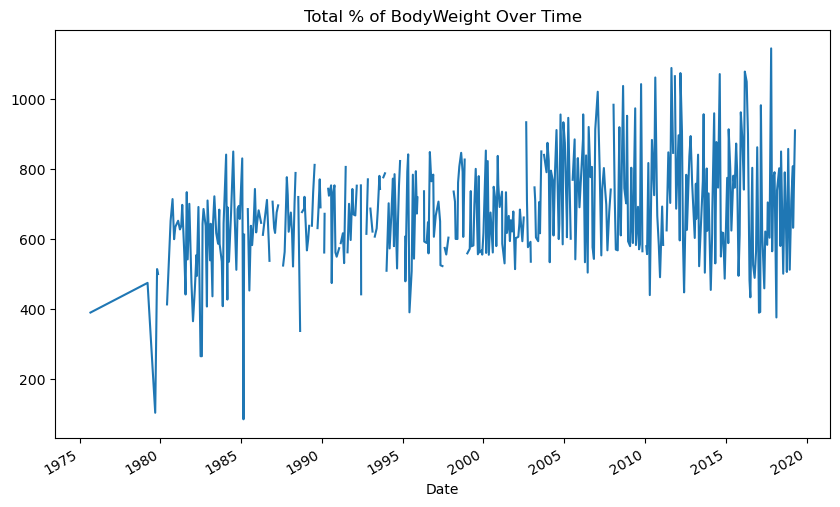

In [14]:
#Start Visualizing 
plt.figure(figsize=(10, 6))
df["Total_pct"].plot(title="Total % of BodyWeight Over Time")
plt.show()

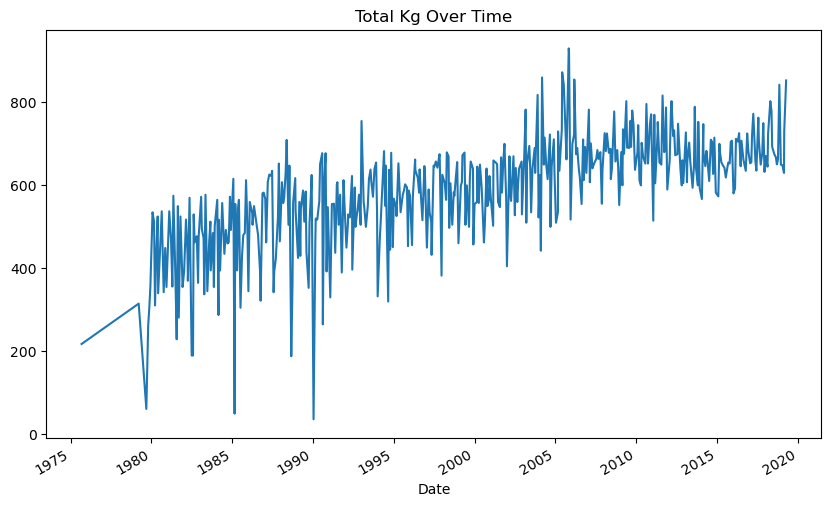

In [15]:
#Start Visualizing 
plt.figure(figsize=(10, 6))
df["TotalKg"].plot(title="Total Kg Over Time")
plt.show() 

As expected, this shows a clear upwards trend over time with numerous outliers and anomalies as well as nosie. This will have to undergo extensive smoothing. There appears to be less noise in the Total Kg rather than Total as a percentage of bodyweight, so I decided to go with TotalKg as the target.
The upward trend is perhaps due to the growing acceptance of muscle on women and new knowledge around nutrition in addition to the proliferation of perfomance enhancing drugs even if the competitions test for it. No seasonality at the moment from this. Most the big international competitions are between March and October.

## Missing Values, Outliers, and Handling 

In [16]:
#Missing Values
df.isna().sum()

missing_summary = pd.DataFrame({
    "missing_percent": df.isna().mean() * 100,
    "missing_count": df.isna().sum()
}).round(2)

missing_summary

,missing_percent,missing_count
Name,0.00,0
Sex,0.00,0
Event,0.00,0
Equipment,0.00,0
Age,24.20,114
Division,3.82,18
BodyweightKg,9.55,45
TotalKg,0.00,0
Place,0.00,0
Tested,43.52,205


In [17]:
df['Event'].value_counts() #The traditional competition is SBD Squat Bench and Deadlift. I'm dislcuding the other variations

Event
SBD    465
B        3
SB       2
D        1
Name: count, dtype: int64

In [18]:
df = df.drop(df[df['Event'].isin(['B', 'SB', 'D'])].index)

The missing in the tested is probably historical and I will likely fill in those values as "Not tested" or turn the whole column into a 1/0 binary.

In [19]:
#Turn Tested Nas into Binary with 1=tested and 0=untested
df['Tested_binary'] = (df['Tested']== 'Yes').astype(int) 
df['Tested_binary'].value_counts()

Tested_binary
1    263
0    202
Name: count, dtype: int64

In [20]:
#How gain more information about the missing age
missing_age = df[df['Age'].isna()]
missing_age #Seems to be widespread. This is a case where I would substitute in the mean age
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [21]:
#Drop all rows where Bodyweight is NA
df = df.dropna(subset=['BodyweightKg'])

In [22]:
#Missing Country 122 Missing entries for the native country of the competitior
missing_country = df[df["Country"].isna()]
missing_country.info()
missing_country['MeetCountry'].value_counts() #No relation to this

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 104 entries, 1975-09-05 to 2019-03-01
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   Name           104 non-null    object   
 1   Sex            104 non-null    object   
 2   Event          104 non-null    object   
 3   Equipment      104 non-null    object   
 4   Age            104 non-null    float64  
 5   Division       100 non-null    object   
 6   BodyweightKg   104 non-null    float64  
 7   TotalKg        104 non-null    float64  
 8   Place          104 non-null    object   
 9   Tested         30 non-null     object   
 10  Country        0 non-null      object   
 11  Federation     104 non-null    object   
 12  MeetCountry    104 non-null    object   
 13  MeetName       104 non-null    object   
 14  YearMonth      104 non-null    period[M]
 15  year           104 non-null    int32    
 16  month          104 non-null    int32    
 1

MeetCountry
USA            78
Russia          6
Norway          4
Japan           3
UK              3
Canada          3
New Zealand     2
Ukraine         2
Germany         1
Iceland         1
Australia       1
Name: count, dtype: int64

In [23]:
df.loc[df['Country'].isna()].index.year.value_counts().sort_index()

Date
1975    1
1979    3
1980    2
1981    5
1982    6
1983    6
1984    3
1985    3
1986    5
1987    5
1988    2
1989    3
1990    3
1991    4
1992    1
1994    3
1995    1
1998    1
1999    2
2000    1
2001    1
2002    1
2003    1
2005    1
2006    1
2007    2
2008    3
2009    2
2010    1
2011    3
2012    4
2013    2
2014    3
2015    3
2016    6
2017    6
2018    2
2019    2
Name: count, dtype: int64

Missing country by date shows no discernable pattern. In a more involved project, I could go through the entire list of 122 athletes and insert the missing data. For the time being, I'm going to drop the country of origin as a column. It's sad because I feel this could be an interested factor here. And you could look at the association between people lifting winning weights and their being in their home country or not, etc. But the alternative would be to drop those rows which means compromising the time series intactness.

In [24]:
#Also dropping Tested as I turned this into a binary
#And Sex because it's redunant as is Place - most of the entries won first place with few exceptions
df = df.drop(columns=['Country','Tested','Sex','Place'])

We see a multitude of divisions here some oriented toward younger women and older women. The majority of lifts occur in the Open division. I'm going ot collapse the divisions that "age anomalous" or other into a category of "other". I'm also assuming the division of "O" is open. 


In [25]:
#Collapsing "O" into Open
df['Division'] = df['Division'].replace({
    'O': 'Open',
    'Pro Open': 'Pro'
})
#Collapsing all the small divisions and Juniors into "Other"
df['Division'] = df['Division'].where(
    df['Division'].isin(['Pro', 'Open']),
    'Other'
)
#Should be left with three divisions: Open, Pro and Other
df['Division'].value_counts()

Division
Open     291
Other    111
Pro       19
Name: count, dtype: int64

In [26]:
#Recheck missing - No missing data
df.isna().sum()

Name             0
Event            0
Equipment        0
Age              0
Division         0
BodyweightKg     0
TotalKg          0
Federation       0
MeetCountry      0
MeetName         0
YearMonth        0
year             0
month            0
Total_pct        0
Tested_binary    0
dtype: int64

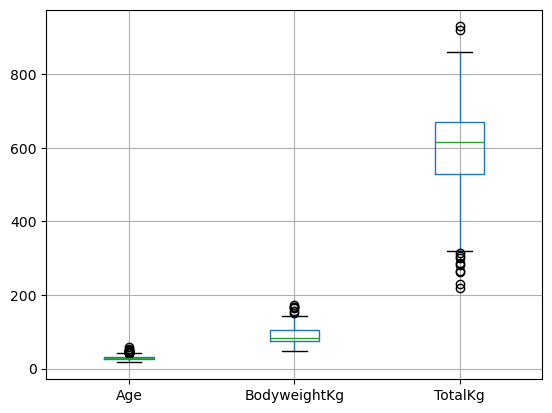

In [27]:
#Look at Outliers with Boxplots
df[['Age', 'BodyweightKg', 'TotalKg']].boxplot()
plt.show()

#These show few outliers with the exception of TotalKg which may be capture the historical trend here of more and mroe weight

In [28]:
df.columns

Index(['Name', 'Event', 'Equipment', 'Age', 'Division', 'BodyweightKg',
       'TotalKg', 'Federation', 'MeetCountry', 'MeetName', 'YearMonth', 'year',
       'month', 'Total_pct', 'Tested_binary'],
      dtype='object')

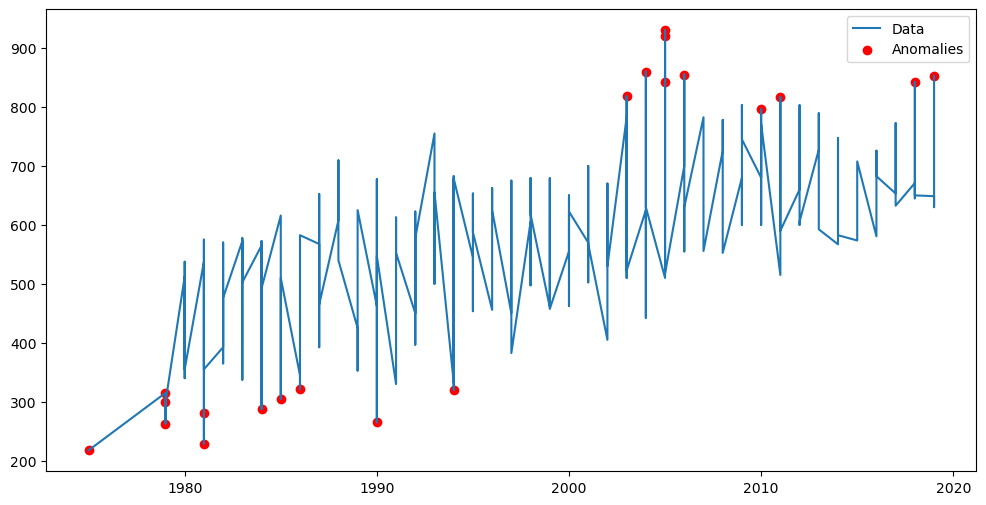

Number of anomalies detected: 21


In [29]:
#Using a more robust method of anomaly detection and run it based on year

from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(df[['TotalKg']])

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['TotalKg'], label='Data')
plt.scatter(df['year'][df['anomaly_score'] == -1], df['TotalKg'][df['anomaly_score'] == -1], color='red', label='Anomalies')
plt.legend()
plt.show()

n_anomalies = (df['anomaly_score'] == -1).sum()
print("Number of anomalies detected:", n_anomalies)

This shows quite a few anomalies at the lower kg end of the earlier  years and the top most kg lifts towards the end of the dataset, which is to be expected. Overall there are 21. From the table below you can see that most were attributed to heavy lifts. I'm choosing to retain the anomalies because I think they are an important part of the story in the upward trend in women's lifting.

In [30]:
anomaly_rows = df[df['anomaly_score'] == -1]
anomaly_rows

,Name,Event,Equipment,Age,Division,BodyweightKg,TotalKg,Federation,MeetCountry,MeetName,YearMonth,year,month,Total_pct,Tested_binary,anomaly_score
Date,,,,,,,,,,,,,,,,
1975-09-05,Natalie Kahn,SBD,Wraps,29.607843,Open,56.00,217.72,AAU,USA,First All Women's Powerlifting Contest,1975-09,1975,9,388.785714,1,-1
1979-03-19,Tone Næss,SBD,Single-ply,29.607843,Open,66.50,315.00,NSF,Norway,NM Damer,1979-03,1979,3,473.684211,1,-1
1979-10-20,Monkee Caldwell,SBD,Single-ply,29.607843,Open,51.26,263.08,USMilAbroad,Germany,Americans In Europe Meet,1979-10,1979,10,513.226687,0,-1
1979-11-11,K. Kelley,SBD,Single-ply,29.607843,Open,60.00,299.37,USPF,USA,Tampa Novice & Women's Championships,1979-11,1979,11,498.950000,0,-1
1981-07-25,T. Walden,SBD,Single-ply,29.607843,Open,52.00,229.06,USPF,USA,Florida State Championships,1981-07,1981,7,440.500000,0,-1
1981-09-10,Cathy Kestel,SBD,Single-ply,29.607843,Open,52.00,281.23,USPF,USA,North Canton Fall Classic,1981-09,1981,9,540.826923,0,-1
1984-02-25,Linda Slutnik,SBD,Single-ply,29.607843,Open,67.50,287.50,CPU,Canada,APU Provincials,1984-02,1984,2,425.925926,1,-1
1985-07-06,Sigurbjörg Kjartansdóttir,SBD,Single-ply,32.500000,Open,67.50,305.00,KRAFT,Iceland,Miðsumarsmót í kraftlyftingum,1985-07,1985,7,451.851852,1,-1
1986-10-04,Judy Watson,SBD,Single-ply,29.607843,Other,60.00,322.05,USPF,USA,Police & Fire Grand Nationals,1986-10,1986,10,536.750000,0,-1


## Study Variables: Use Value, Type, Noise, Distributions


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'BodyweightKg'}>,
        <Axes: title={'center': 'TotalKg'}>],
       [<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'Total_pct'}>],
       [<Axes: title={'center': 'Tested_binary'}>,
        <Axes: title={'center': 'anomaly_score'}>, <Axes: >]],
      dtype=object)

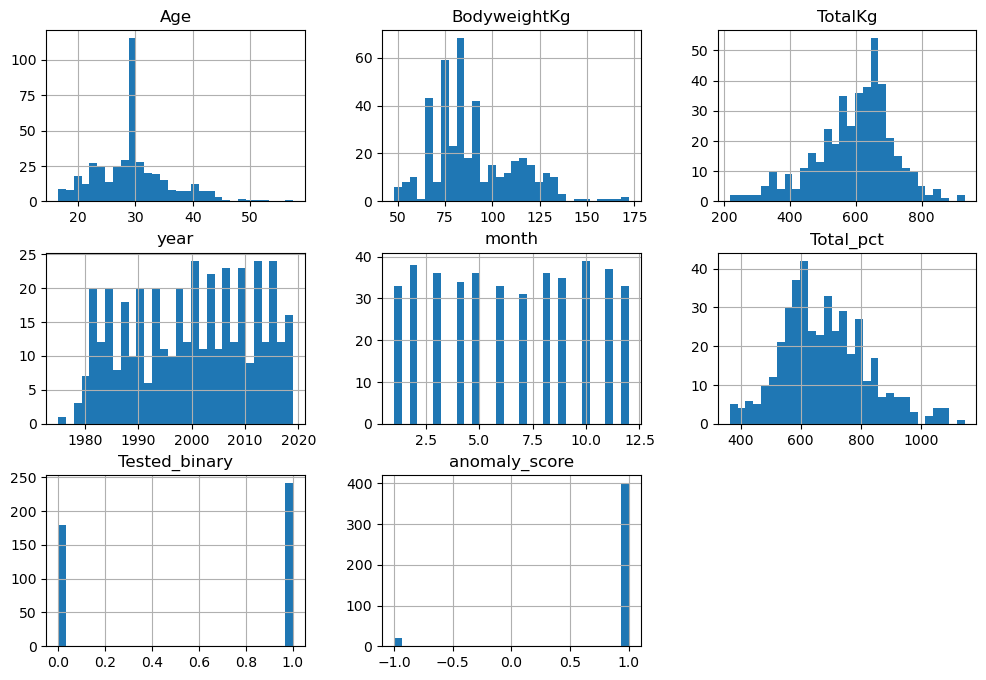

In [31]:
#Generate histograms of the variables I want to focus on. Consider usevalue, type, noise, and distribution
df.hist(figsize=(12, 8), bins=30)


These show three numeric variables and as discussed before, the bodyweight and age seem to be concentrated around a fair bell curve but one that has large standard deviations. 

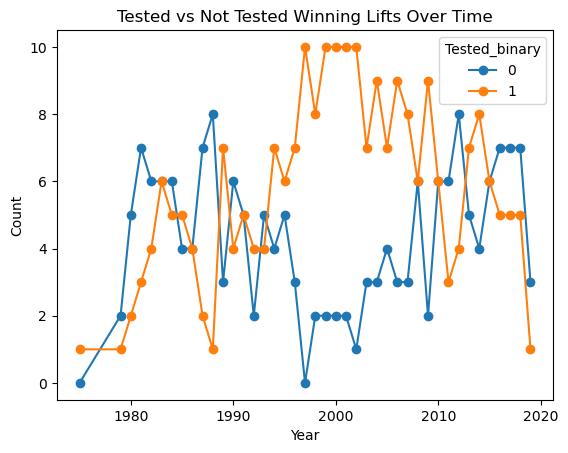

In [32]:
#Breakdown of tested_binary by year
tested = pd.crosstab(df.index.year, df['Tested_binary'])
tested.plot(kind='line', marker='o')
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Tested vs Not Tested Winning Lifts Over Time")
plt.legend(title="Tested_binary")
plt.show()


This is interesting. I would need to look into how testing entered the sport a bit more.
The divide on the same years means there are some comps that test and some that do not. 
The graph shows an intense period of scrutiny between the late 1990s and 2010 where testing seems to be netting the results it wants: People are performing the best at comps that test rather than those that don't interestingly

In [33]:
#Quick Look at the Categoricals: 

#How many competitors are here?
print("Number Competitors:", len(df['Name'].unique()))
#How many competitions? It is mostly the SBD
print("Number of Annual Competitions:", len(df['MeetName'].unique()))
#Open versus Pro - Most in the open division
df['Division'].value_counts().head(20)

Number Competitors: 210
Number of Annual Competitions: 217


Division
Open     291
Other    111
Pro       19
Name: count, dtype: int64

In [34]:
#Equipment breakdown
df['Equipment'].value_counts()

Equipment
Single-ply    318
Multi-ply      85
Raw            11
Wraps           7
Name: count, dtype: int64

Equipment refers to what belts, wraps and suits were used. Raw indicates no equipment used. Wraps allows knee wraps for the squat. Singlel-ply is a suportive suit with minimum material and multi-ply is a suit with more structural support. So I would expect that the heaviest lifting happens with those support systems. Since my focus was on sheer total weight here, it makes sense that the subset would capture competitions that allow more support. I chose to leave this as is since it is such a huge point of contention in the field.

In [35]:
#The Location of the Meet 
df['MeetCountry'].value_counts().head()

MeetCountry
USA          194
Russia        48
Ukraine       24
Australia     18
Czechia       11
Name: count, dtype: int64

In [36]:
df['Name'].value_counts() #Indicates a concentrated among a top competitiors

Name
Olga Gemaletdinova     16
Galina Karpova         15
Dawn Reshel-Sharon     12
Laura Phelps-Sweatt    11
Chia-Sui Lee           10
                       ..
Leanne Johnson          1
Anne Aanensen           1
D. Young                1
Olena Zhukova           1
Jessica Bowersock       1
Name: count, Length: 210, dtype: int64

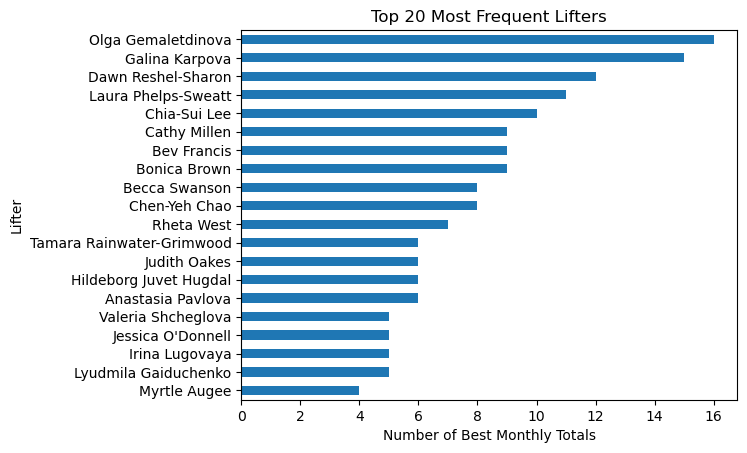

In [37]:
#Top ten athletes
top_20 = df['Name'].value_counts().head(20)
top_20.sort_values().plot(kind='barh')
plt.xlabel("Number of Best Monthly Totals")
plt.ylabel("Lifter")
plt.title("Top 20 Most Frequent Lifters")
plt.show()

## Decomposition: Additive

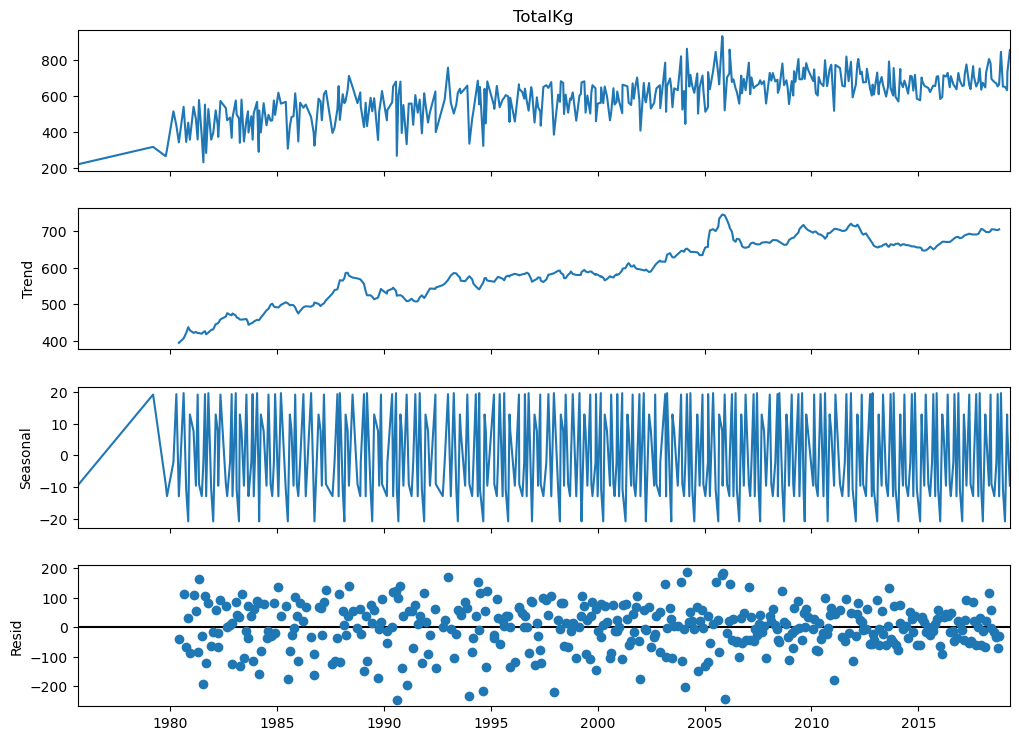

In [38]:
decomp = seasonal_decompose(df["TotalKg"], model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.show()
#I tried the multiplicative and it looks exactly the same

I'm fairly pleased with this at the moment. It shows a clear trend, indicates seasonality and the residuals do not adhere to any discernable pattern albeit there may be some funneling happening at the left most side of the plot.

## Stationarity Diagnostics

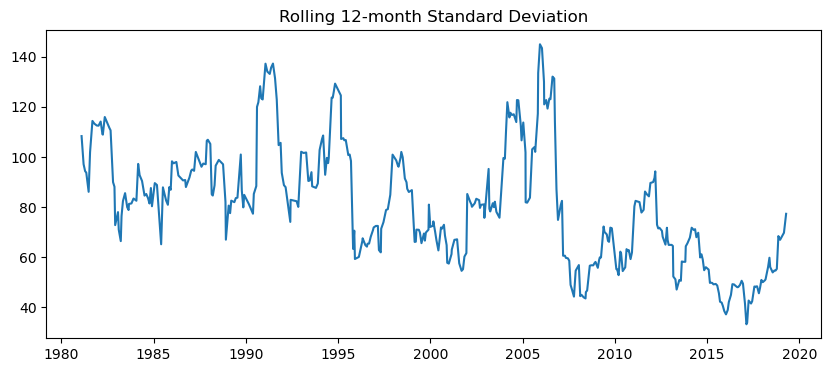

In [39]:
#Check the variance

rolling_std = df["TotalKg"].rolling(window=12).std()

plt.figure(figsize=(10,4))
plt.plot(rolling_std)
plt.title("Rolling 12-month Standard Deviation")
plt.show()

This shows the variance to be quite erratic indicating a need log the target variable

In [40]:
#Test for stationarity. 

def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("The data is stationary (null hypothesis rejected).")
    else:
        print("The data is not stationary (fail to reject the null hypothesis).")

print("Dickey-Fuller Test for Sales:")
adf_test(df["TotalKg"])

Dickey-Fuller Test for Sales:
ADF Statistic: -1.6410682567465384
p-value: 0.46170265219420514
Critical Values:
   1%: -3.4465596717208813
   5%: -2.8686852499495843
   10%: -2.570576203741901
The data is not stationary (fail to reject the null hypothesis).


The DF test indicates that the data is NOT stationary so we will need to apply smoothing to even out the trend. The variance also very nonlinear.



## Correlation and Autocorrelation Diagnostics

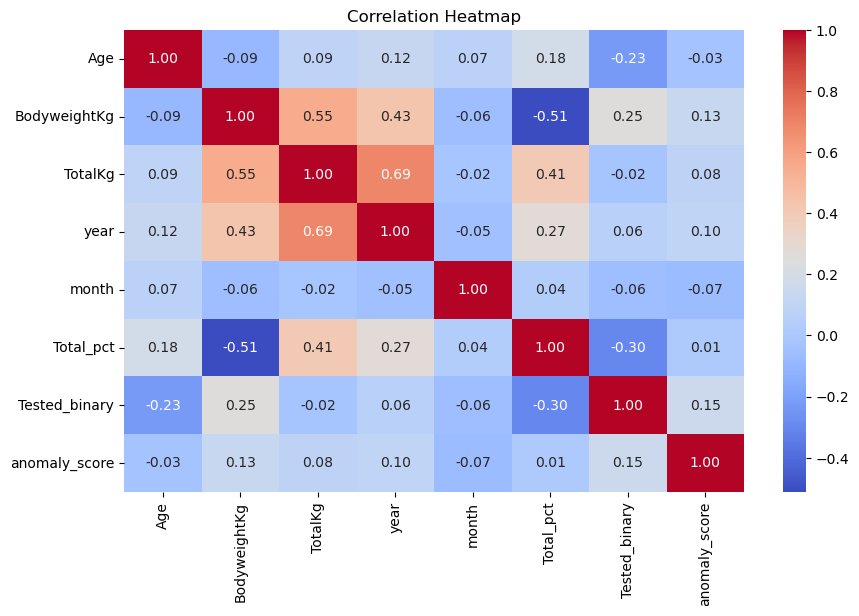

In [41]:
corr = df.corr(numeric_only=True) 

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show() 

This doesn't particularly tell us anything of note. We would expect TotalKg to be correlated with BodyweightKg. If I really wanted to do this properly I would have to go back and calcualte the Totalkg as a percentage of competitor body weight. 

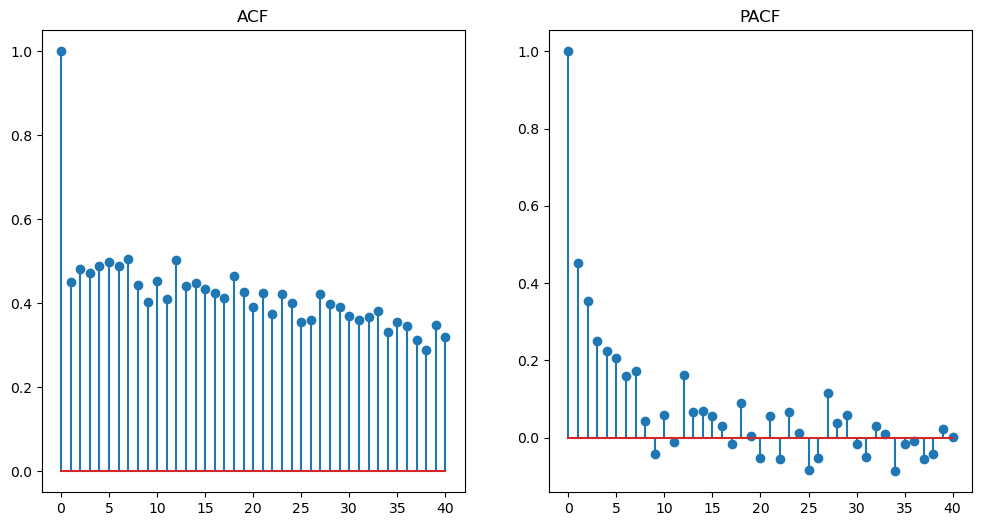

In [42]:
lag_acf = acf(df['TotalKg'], nlags=40)
lag_pacf = pacf(df['TotalKg'], nlags=40) 

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.stem(lag_acf)
plt.title("ACF")
plt.subplot(122)
plt.stem(lag_pacf)
plt.title("PACF")
plt.show()


Shows a overall ACT decline but with disruptions and reversals. This indicates the while there is a trend here, the previous data predicts the future data with diminshing precision and the trend has shorter and shorter memory as time goes on. This could be due to the fact that variance is so erratic

## Transformations to Stabilize


In [1]:
df['TotalKg_log'] = np.log(df['TotalKg'])

plt.plot(df['TotalKg_log'])
plt.title("Log-transformed TotalKg")
plt.ylabel("logTotalKg")
plt.show()
adf_test(df["TotalKg_log"]) #I forgot to pass the log and differenced AR through the Holt Winters!!! wack!

NameError: name 'np' is not defined

The nonstationarity is reduced but not treated

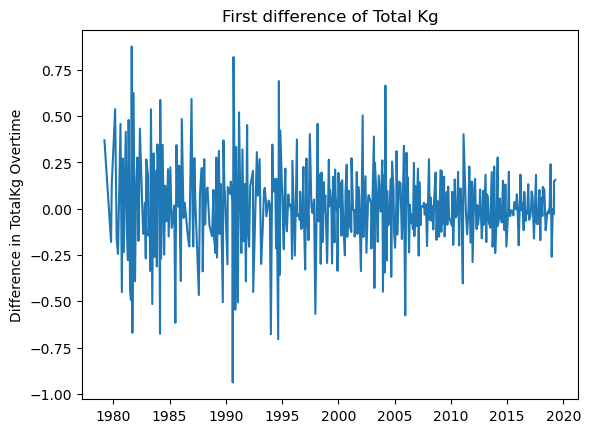

In [44]:
#First difference (remove non-seasonal trend)

df['TotalKg_1diff'] = df['TotalKg_log'].diff().dropna()

plt.plot(df['TotalKg_1diff'])
plt.title("First difference of Total Kg")
plt.ylabel("Difference in TotalKg Overtime")
plt.show()
#Very effective in reducing the trend

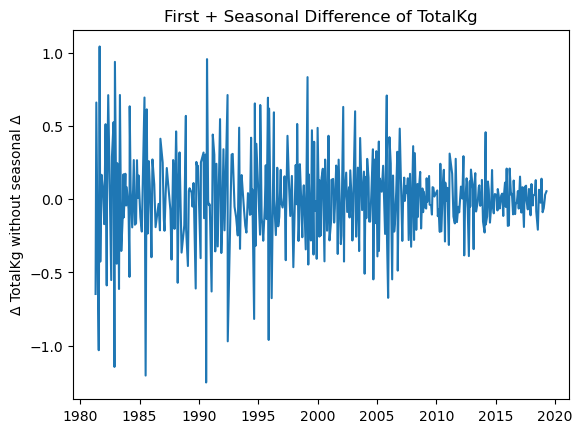

In [45]:
#Seasonal differencing (remove seasonality of period 12)
TotalKg_diff_s = df['TotalKg_1diff'].diff(12).dropna()

plt.plot(TotalKg_diff_s)
plt.title("First + Seasonal Difference of TotalKg")
plt.ylabel("Δ TotalKg without seasonal Δ")
plt.show()

In [46]:
#Re-test adf:
adf_test(TotalKg_diff_s)

ADF Statistic: -9.594293330882122
p-value: 1.9974538215318601e-16
Critical Values:
   1%: -3.4472291365835566
   5%: -2.8689795375849223
   10%: -2.5707330834976987
The data is stationary (null hypothesis rejected).


**The data is now stationary and ready for modeling**

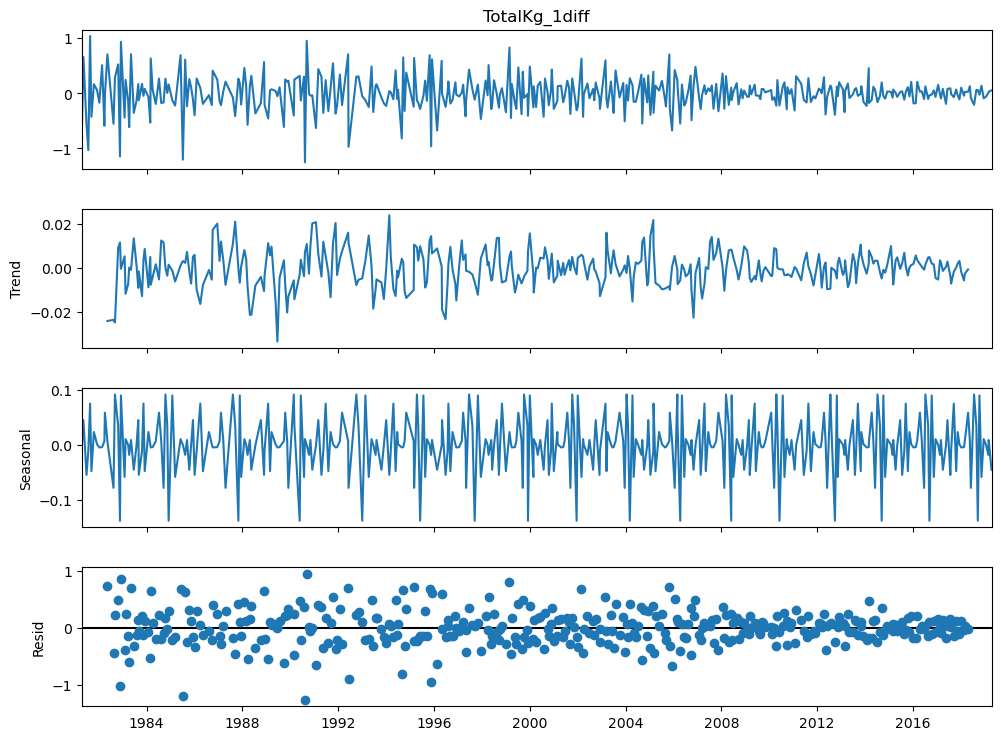

In [47]:
decomp = seasonal_decompose(TotalKg_diff_s, model="additive", period=24)
fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.show()

The updated decomp shows that the trend has been removed and seasonality becomes clear. However, the funneling in the residuals is worse

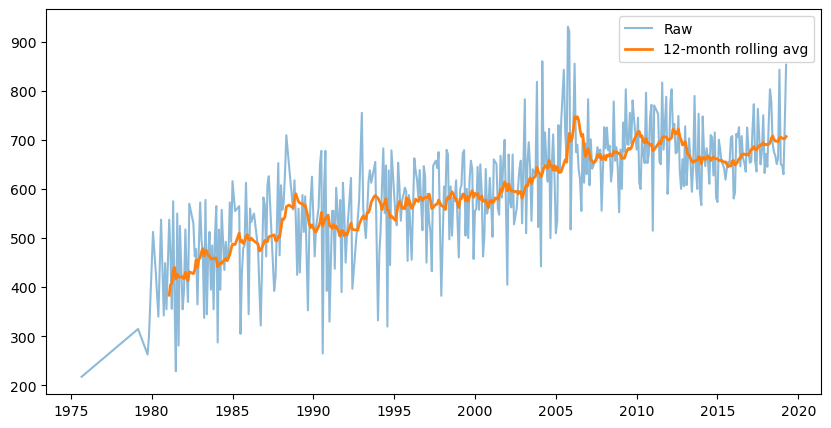

In [48]:
#Rolling Average Reveals a much clearer trend. But this was also captured by the decomposition as well. 
#It creates a nice picture but there is no prediction capacity 

df = pd.DataFrame({
    "YearMonth": df["YearMonth"].dt.to_timestamp() if hasattr(df["YearMonth"], "dt") else df["YearMonth"],
    "TotalKg": df["TotalKg"]
})
    

df["roll"] = df["TotalKg"].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df["YearMonth"], df["TotalKg"], alpha=0.5, label="Raw")
plt.plot(df["YearMonth"], df["roll"], linewidth=2, label="12-month rolling avg")
plt.legend()
plt.show()

In [57]:
#Prepping for Holts - it won't take my yearmonth combo
#I must build a separate dataframe for Holts Winter

#Create a backup copy
df_holt = df.copy().drop(columns='roll') #This captures everything we've done to the df up until this point

#Set frequency to monthly 
df_holt = df_holt.sort_values('YearMonth').set_index('YearMonth')
df_holt = df_holt.asfreq('MS')

#Smooth the nans
df_holt['TotalKg'] = (
    pd.to_numeric(df_holt['TotalKg'], errors='coerce')
    .interpolate(method='time')
)

#Check for missing
df_holt.isna().sum()



TotalKg    0
dtype: int64

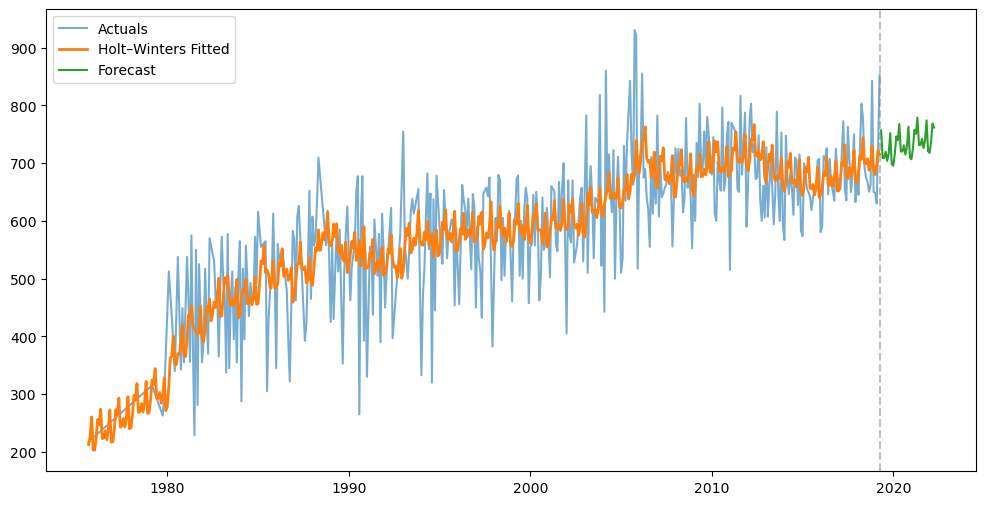

In [59]:
# Fit Holt–Winters on y series
model = ExponentialSmoothing(
    df_holt['TotalKg'], trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated"
)
fit = model.fit()
forecast = fit.forecast(36) #36 steps or 3 years

#Plot all three lines
plt.figure(figsize=(12, 6))
plt.plot(df_holt.index, df_holt['TotalKg'], label="Actuals", alpha=0.6)
plt.plot(df_holt.index, fit.fittedvalues, label="Holt–Winters Fitted", linewidth=2)
plt.plot(forecast.index, forecast.values, label="Forecast")
plt.axvline(x=df_holt.index[-1], color="gray", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

I'm fairly happy with this prediction. It seems realistic albeit it still seems to have quite high variance. I believe the straight line to the far left is the result of Nans popping up when I set the frequency to a Holt-friendly format and then imputed those values based on time.

<h2 id="Summary-Reflection">Summary Reflection</h2>

1. **A brief summary explaining the attributes of the series. Is there a clear trend? Is the trend linear? Is there seasonality?**

The decomposition showed a clear upwards trend that was nonlinear so a log was applied to start. There was clear seasonality as well. Stationarity was obtained through log-transform, and 1st and seasonal differencing.

2.  **A brief reflection of the exercise. Are there any aspects that you struggled with? Did you learn anything interesting?**
   -  It would be intersesting to break this into the separate lifts and analyize how they have trended over time. Has one exploded while the other remained the same? etc.
   -  I chose a difficult dataset because I had to apply a lot of effort to get this into the shape of a time series dataset. But it gave me a better understanding of what those criteria need to be
   -  The biggest thing I took away from this exercise is to be very mindful tracking all the changes I am making to the data. I feel there are lots of modeling options here depending on how you want to transform the data to suit certian models and not others. I expected times series to be more rigid in its protocols and not as flexible and nuanced. 
